# 🌲 Bagging Pipeline — Used Cars Price Classification

**Ensemble Method:** Bagging (Bootstrap Aggregating) via **Random Forest**

**Target:** Price category (Budget / Mid-range / Premium / Luxury)

**Metrics:** Accuracy · F1 · Precision · Recall · ROC-AUC · Confusion Matrix · Classification Report

## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

SEED = 42
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load & Preview Data

In [2]:
df = pd.read_csv('used_cars.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())

--- Data Types ---
brand             str
model             str
model_year      int64
milage            str
fuel_type         str
engine            str
transmission      str
ext_col           str
int_col           str
accident          str
clean_title       str
price             str
dtype: object

--- Missing Values ---
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


## 3. Feature Engineering

In [4]:
def preprocess(df):
    data = df.copy()

    # --- Parse price (target) ---
    data['price_num'] = (
        data['price']
        .str.replace(r'[$,]', '', regex=True)
        .astype(float)
    )

    # --- Parse mileage (fixed: extract digits only to avoid stripping decimal digits) ---
    data['mileage_num'] = (
        data['milage']
        .str.replace(',', '', regex=False)
        .str.extract(r'(\d+)')[0]
        .astype(float)
    )

    # --- Extract horsepower from engine string ---
    data['horsepower'] = (
        data['engine']
        .str.extract(r'(\d+\.?\d*)HP')[0]
        .astype(float)
    )

    # --- Extract engine displacement ---
    data['displacement'] = (
        data['engine']
        .str.extract(r'(\d+\.?\d*)L')[0]
        .astype(float)
    )

    # --- NEW: Number of cylinders ---
    data['num_cylinders'] = (
        data['engine']
        .str.extract(r'(\d+)\s*Cylinder')[0]
        .astype(float)
    )

    # --- NEW: Turbo flag ---
    data['has_turbo'] = (
        data['engine']
        .str.contains('Turbo|Turbocharged', case=False, na=False)
        .astype(int)
    )

    # --- NEW: Electric motor flag ---
    data['is_electric'] = (
        data['engine']
        .str.contains('Electric', case=False, na=False)
        .astype(int)
    )

    # --- NEW: Power density (HP per litre) — signals sporty/performance trim ---
    data['hp_per_liter'] = data['horsepower'] / data['displacement'].replace(0, float('nan'))

    # --- Car age ---
    data['car_age'] = 2025 - data['model_year']

    # --- Binary flags ---
    data['has_accident'] = data['accident'].str.contains('accident', case=False, na=False).astype(int)
    data['clean_title_flag'] = (data['clean_title'] == 'Yes').astype(int)

    # --- Transmission type ---
    data['is_automatic'] = data['transmission'].str.contains('A/T|Automatic|CVT|DCT', case=False, na=False).astype(int)

    # --- NEW: Number of transmission speeds ---
    data['trans_speeds'] = (
        data['transmission']
        .str.extract(r'(\d+)-Speed')[0]
        .astype(float)
    )

    return data

data = preprocess(df)

# --- Create price classes ---
bins = [0, 15000, 30000, 55000, float('inf')]
labels = ['Budget', 'Mid-range', 'Premium', 'Luxury']
data['price_class'] = pd.cut(data['price_num'], bins=bins, labels=labels)

print('Price class distribution:')
print(data['price_class'].value_counts().sort_index())

Price class distribution:
price_class
Budget        830
Mid-range    1130
Premium      1244
Luxury        805
Name: count, dtype: int64


## 4. Exploratory Data Analysis

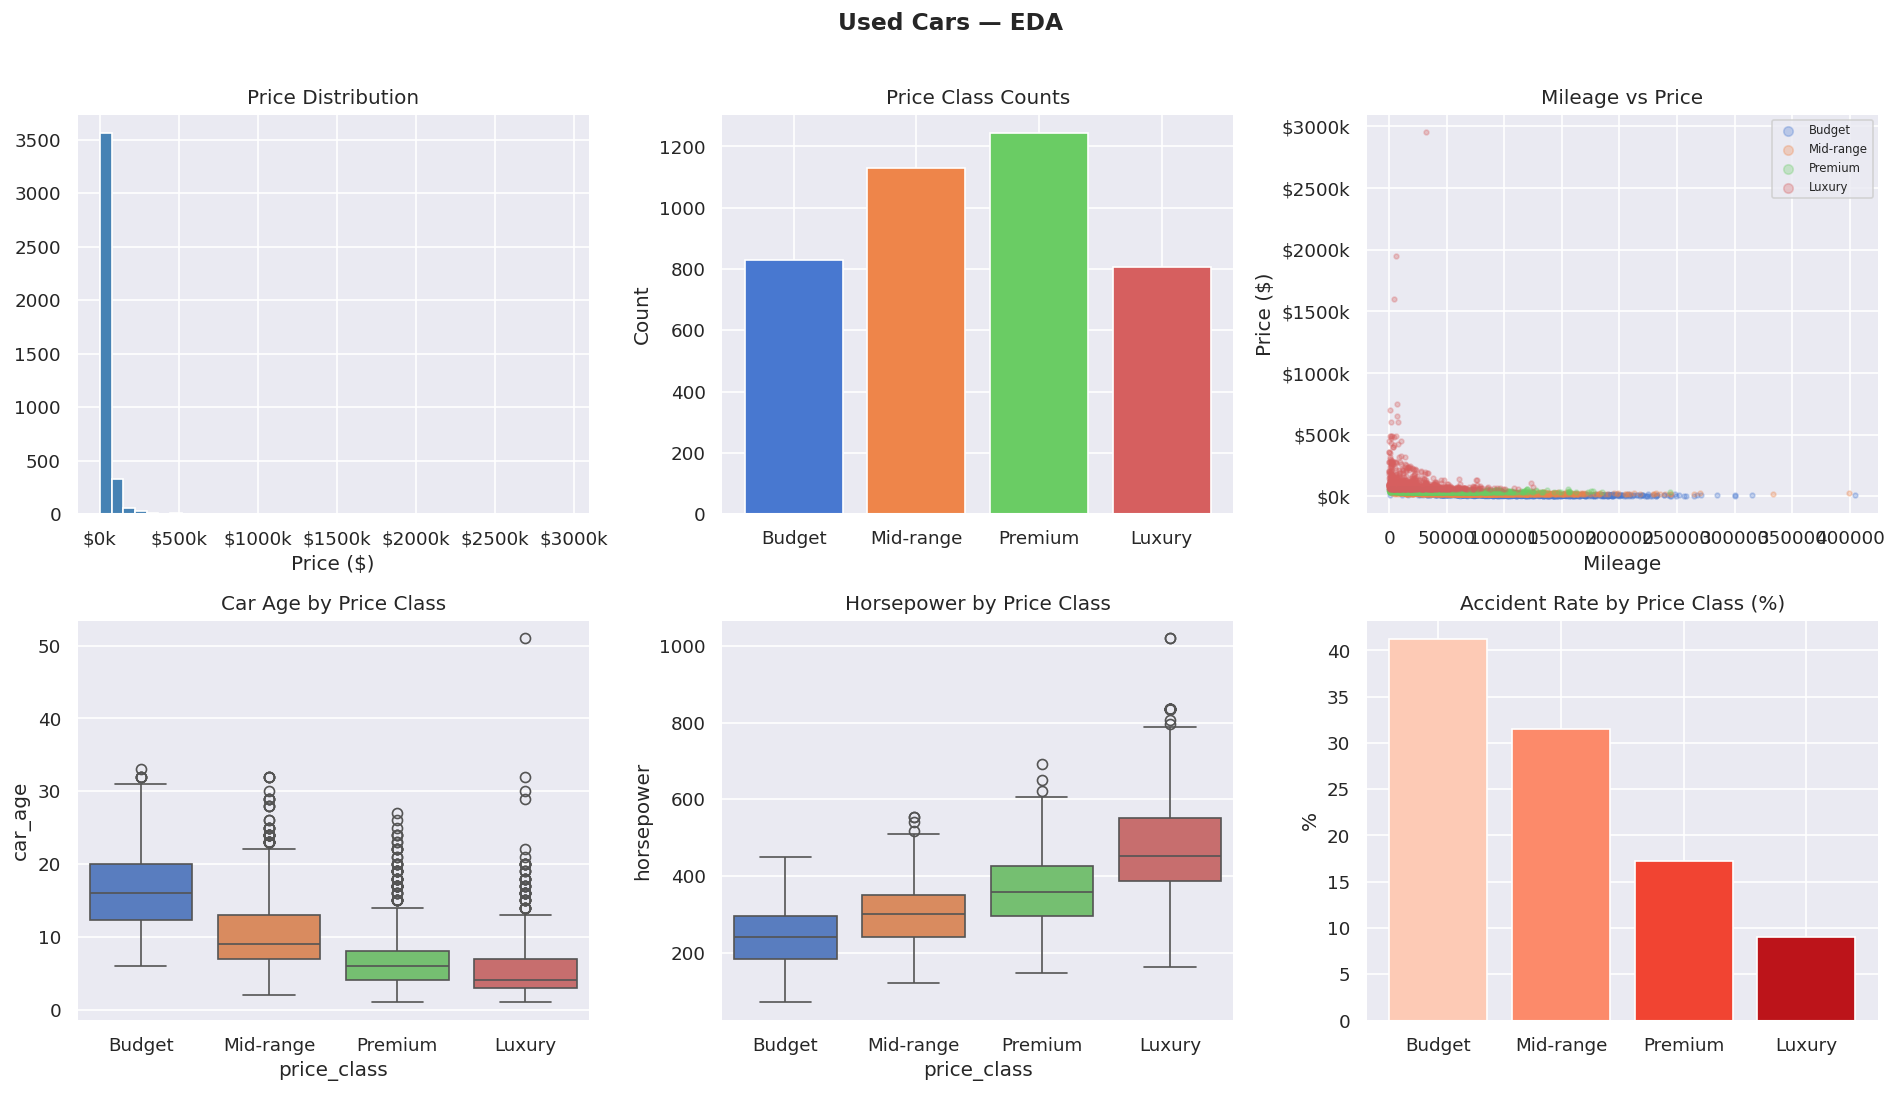

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Price distribution
axes[0,0].hist(data['price_num'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price ($)')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

# Price class counts
vc = data['price_class'].value_counts().sort_index()
axes[0,1].bar(vc.index.astype(str), vc.values, color=sns.color_palette('muted', 4))
axes[0,1].set_title('Price Class Counts')
axes[0,1].set_ylabel('Count')

# Mileage vs Price
for cls, col in zip(labels, sns.color_palette('muted', 4)):
    sub = data[data['price_class'] == cls]
    axes[0,2].scatter(sub['mileage_num'], sub['price_num'], alpha=0.3, s=8, color=col, label=cls)
axes[0,2].set_title('Mileage vs Price')
axes[0,2].set_xlabel('Mileage')
axes[0,2].set_ylabel('Price ($)')
axes[0,2].legend(fontsize=7, markerscale=2)
axes[0,2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

# Car age vs Price class
sns.boxplot(data=data, x='price_class', y='car_age', ax=axes[1,0], palette='muted')
axes[1,0].set_title('Car Age by Price Class')

# Horsepower distribution
sns.boxplot(data=data, x='price_class', y='horsepower', ax=axes[1,1], palette='muted')
axes[1,1].set_title('Horsepower by Price Class')

# Accident rate per class
acc_rate = data.groupby('price_class', observed=True)['has_accident'].mean() * 100
axes[1,2].bar(acc_rate.index.astype(str), acc_rate.values, color=sns.color_palette('Reds', 4))
axes[1,2].set_title('Accident Rate by Price Class (%)')
axes[1,2].set_ylabel('%')

plt.suptitle('Used Cars — EDA', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Selection & Train/Test Split

In [6]:
NUMERIC_FEATURES = [
    # Original
    'mileage_num', 'horsepower', 'displacement', 'car_age', 'model_year',
    'has_accident', 'clean_title_flag', 'is_automatic',
    # New engine features
    'num_cylinders', 'has_turbo', 'is_electric', 'hp_per_liter',
    # New transmission feature
    'trans_speeds',
]

# Dropped ext_col / int_col: low importance (~11% total), high cardinality noise
# Added 'model': specific model is a strong price signal (e.g. 'Cayenne' vs '3 Series')
CATEGORICAL_FEATURES = ['brand', 'model', 'fuel_type']

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'price_class'

X = data[ALL_FEATURES].copy()
y = data[TARGET].copy()

# Drop rows where target is NaN
mask = y.notna()
X, y = X[mask], y[mask]
y = y.astype(str)  # ensure string labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('Class balance (train):')
print(pd.Series(y_train).value_counts())

Train: (3207, 12), Test: (802, 12)
Class balance (train):
price_class
Premium      995
Mid-range    904
Budget       664
Luxury       644
Name: count, dtype: int64


## 6. Preprocessing Pipeline

In [7]:
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # max_categories=50 keeps top-50 model names, groups the rest as 'infrequent'
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=50))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print('Preprocessor built ✓')

Preprocessor built ✓


## 7. Bagging Model — Random Forest

**Random Forest** trains `n_estimators` Decision Trees on bootstrap samples of the data  
and aggregates predictions by majority vote → classic **Bagging** strategy.

In [8]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=True,       # <-- Bagging
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
print('Random Forest trained ✓')

Random Forest trained ✓


### 7b. Vanilla Bagging Classifier (Decision Tree base)
For comparison — explicit `BaggingClassifier` wrapper.

In [9]:
bagging_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=10, random_state=SEED),
        n_estimators=200,
        max_samples=0.8,
        max_features=0.8,
        bootstrap=True,
        random_state=SEED,
        n_jobs=-1
    ))
])

bagging_pipeline.fit(X_train, y_train)
print('Bagging Classifier trained ✓')

Bagging Classifier trained ✓


## 8. Evaluation — All Metrics

In [10]:
CLASS_NAMES = sorted(y_train.unique())

def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te, class_names):
    print(f'\n{"="*60}')
    print(f'  MODEL: {name}')
    print(f'{"="*60}')

    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)

    acc       = accuracy_score(y_te, y_pred)
    f1_mac    = f1_score(y_te, y_pred, average='macro')
    f1_mic    = f1_score(y_te, y_pred, average='micro')
    f1_wt     = f1_score(y_te, y_pred, average='weighted')
    prec_mac  = precision_score(y_te, y_pred, average='macro')
    prec_wt   = precision_score(y_te, y_pred, average='weighted')
    rec_mac   = recall_score(y_te, y_pred, average='macro')
    rec_wt    = recall_score(y_te, y_pred, average='weighted')

    # OvR ROC-AUC
    y_bin = label_binarize(y_te, classes=class_names)
    roc   = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')

    # CV accuracy
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(pipeline, X_tr, y_tr, cv=cv, scoring='accuracy', n_jobs=-1)

    metrics = {
        'Accuracy': acc,
        'F1 (Macro)': f1_mac,
        'F1 (Micro)': f1_mic,
        'F1 (Weighted)': f1_wt,
        'Precision (Macro)': prec_mac,
        'Precision (Weighted)': prec_wt,
        'Recall (Macro)': rec_mac,
        'Recall (Weighted)': rec_wt,
        'ROC-AUC (OvR Macro)': roc,
        'CV Accuracy (mean±std)': f'{cv_scores.mean():.4f} ± {cv_scores.std():.4f}'
    }

    print('\n📊 Metrics Summary:')
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f'  {k:<28}: {v:.4f}')
        else:
            print(f'  {k:<28}: {v}')

    print('\n📋 Classification Report:')
    print(classification_report(y_te, y_pred, target_names=class_names))

    return y_pred, y_prob, metrics

rf_pred, rf_prob, rf_metrics = evaluate_model(
    'Random Forest (Bagging)', rf_pipeline, X_train, y_train, X_test, y_test, CLASS_NAMES
)

bag_pred, bag_prob, bag_metrics = evaluate_model(
    'Bagging Classifier (DT base)', bagging_pipeline, X_train, y_train, X_test, y_test, CLASS_NAMES
)


  MODEL: Random Forest (Bagging)

📊 Metrics Summary:
  Accuracy                    : 0.7606
  F1 (Macro)                  : 0.7671
  F1 (Micro)                  : 0.7606
  F1 (Weighted)               : 0.7578
  Precision (Macro)           : 0.7617
  Precision (Weighted)        : 0.7615
  Recall (Macro)              : 0.7793
  Recall (Weighted)           : 0.7606
  ROC-AUC (OvR Macro)         : 0.9294
  CV Accuracy (mean±std)      : 0.7091 ± 0.0138

📋 Classification Report:
              precision    recall  f1-score   support

      Budget       0.73      0.88      0.80       166
      Luxury       0.81      0.89      0.85       161
   Mid-range       0.71      0.65      0.68       226
     Premium       0.80      0.69      0.74       249

    accuracy                           0.76       802
   macro avg       0.76      0.78      0.77       802
weighted avg       0.76      0.76      0.76       802


  MODEL: Bagging Classifier (DT base)

📊 Metrics Summary:
  Accuracy                 

## 9. Confusion Matrices

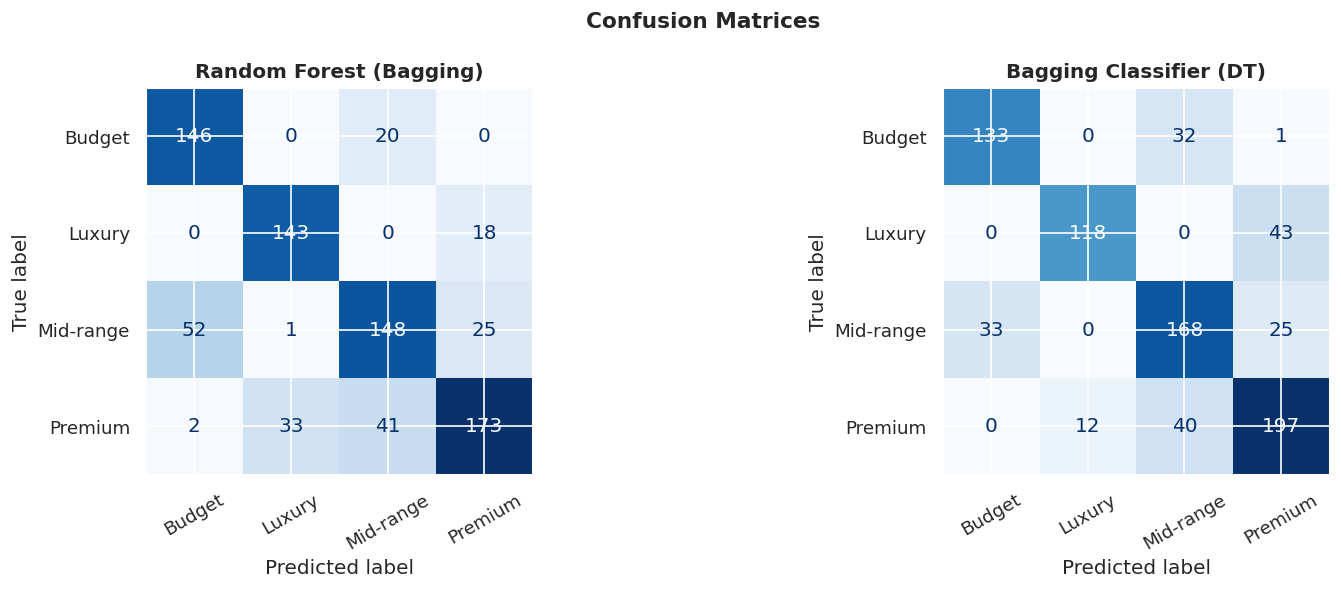

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(
    axes,
    [rf_pred, bag_pred],
    ['Random Forest (Bagging)', 'Bagging Classifier (DT)']
):
    cm = confusion_matrix(y_test, pred, labels=CLASS_NAMES)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. ROC Curves (One-vs-Rest)

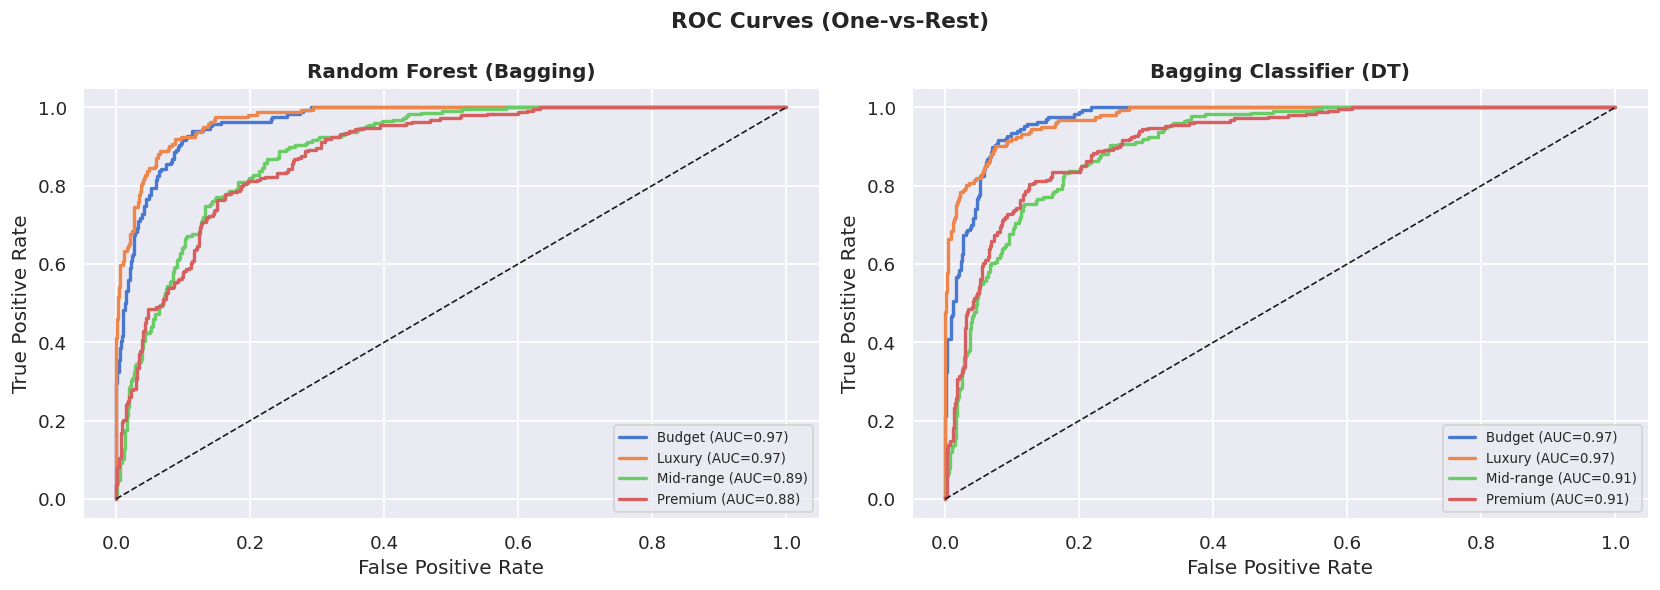

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_bin = label_binarize(y_test, classes=CLASS_NAMES)
colors = sns.color_palette('muted', len(CLASS_NAMES))

for ax, prob, title in zip(
    axes, [rf_prob, bag_prob],
    ['Random Forest (Bagging)', 'Bagging Classifier (DT)']
):
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], prob[:, i])
        roc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, color=col, label=f'{cls} (AUC={roc_val:.2f})')
    ax.plot([0,1],[0,1], 'k--', lw=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)

plt.suptitle('ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Feature Importance (Random Forest)

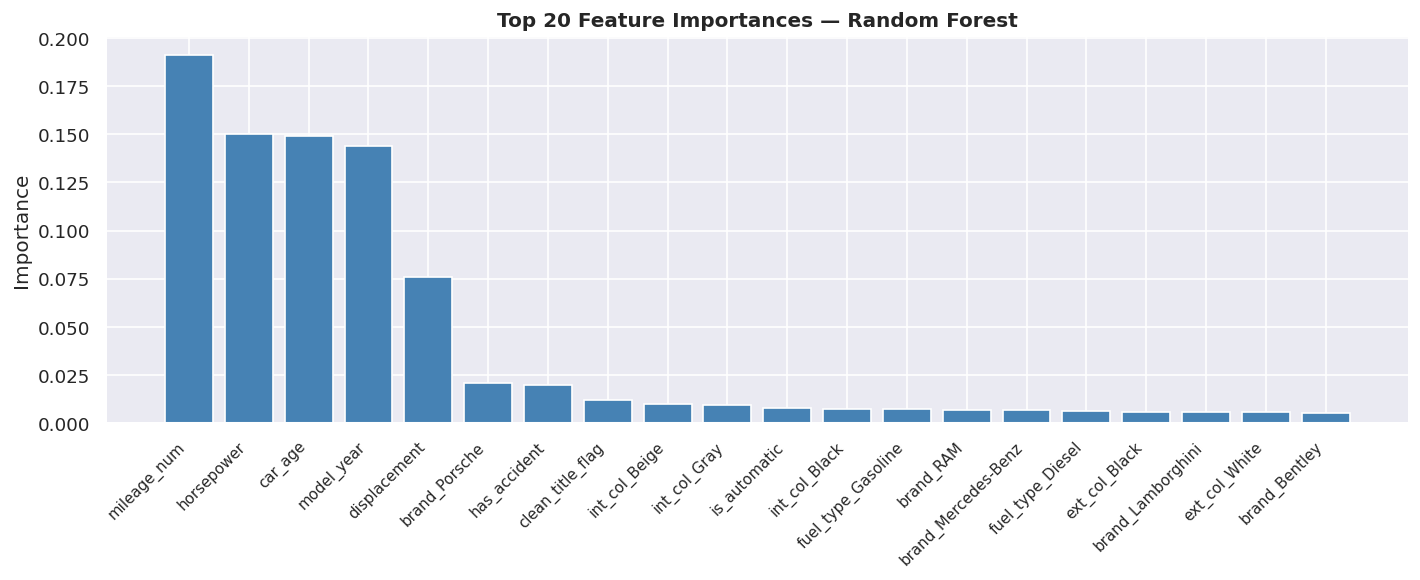

In [13]:
rf_clf = rf_pipeline.named_steps['classifier']
pre    = rf_pipeline.named_steps['preprocessor']

ohe_cols = list(pre.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(CATEGORICAL_FEATURES))
feat_names = NUMERIC_FEATURES + ohe_cols

importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 5))
plt.bar(range(len(indices)), importances[indices], color='steelblue', edgecolor='white')
plt.xticks(range(len(indices)), [feat_names[i] for i in indices], rotation=45, ha='right', fontsize=9)
plt.title('Top 20 Feature Importances — Random Forest', fontweight='bold')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## 12. Metrics Comparison

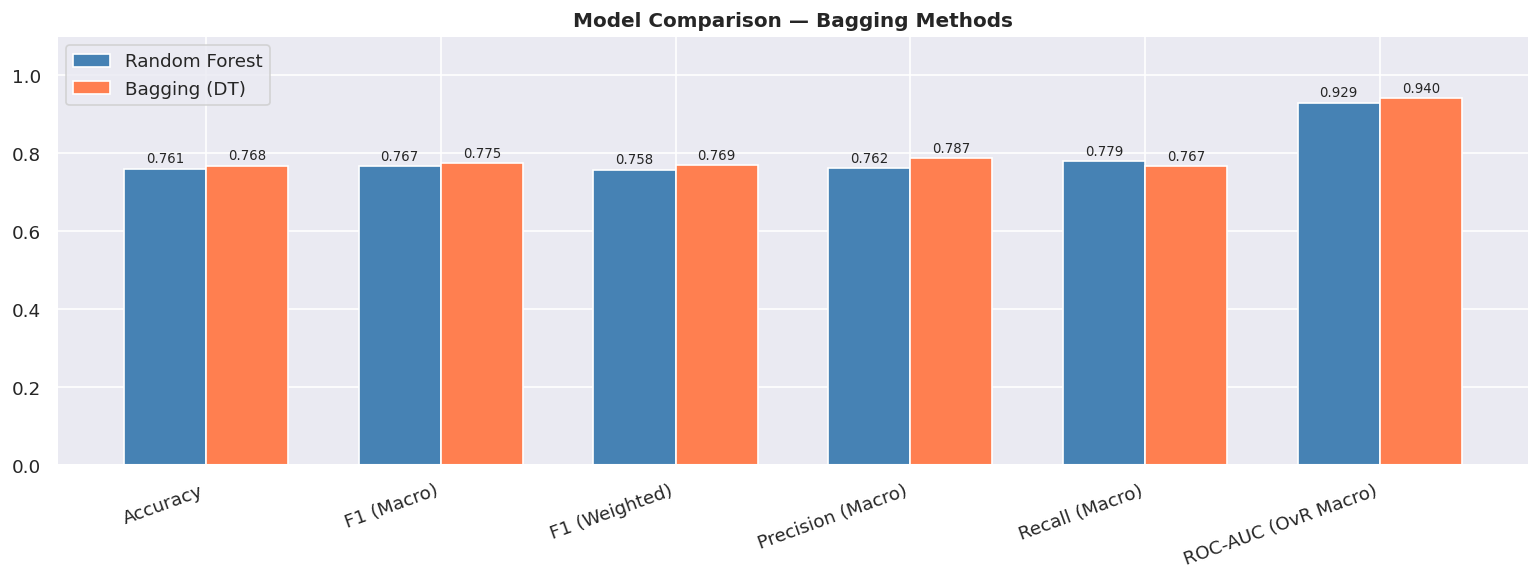


✅ Bagging Pipeline Complete!


In [14]:
compare_keys = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'Precision (Macro)', 'Recall (Macro)', 'ROC-AUC (OvR Macro)']
rf_vals  = [rf_metrics[k] for k in compare_keys]
bag_vals = [bag_metrics[k] for k in compare_keys]

x = np.arange(len(compare_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color='steelblue', edgecolor='white')
b2 = ax.bar(x + width/2, bag_vals, width, label='Bagging (DT)',  color='coral',     edgecolor='white')

ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=2)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(compare_keys, rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison — Bagging Methods', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\n✅ Bagging Pipeline Complete!')